<a href="https://colab.research.google.com/github/mcjkurz/qhchina/blob/main/tutorials/Intro_to_Python_for_Chinese_Humanities_Part_2_Working_with_Texts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Python for Chinese Humanities: Part 2, Working with Texts

## Reading Files

In [ ]:
# Let's first download the text file, a novel "Love in a Fallen City" by Eileen Chang 张爱玲
!wget https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/张爱玲_倾城之恋.txt

--2024-06-17 04:08:19--  https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/%E5%BC%A0%E7%88%B1%E7%8E%B2_%E5%80%BE%E5%9F%8E%E4%B9%8B%E6%81%8B.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 86846 (85K) [text/plain]
Saving to: ‘张爱玲_倾城之恋.txt.1’

张爱玲_倾城之恋.txt 100%[===================>]  84.81K  --.-KB/s    in 0.02s   

2024-06-17 04:08:19 (3.88 MB/s) - ‘张爱玲_倾城之恋.txt.1’ saved [86846/86846]



We use the `open` function to read files. `open` takes two arguments: the name of the file and the mode of access to this file. Here, we use `r` for "read." We need to remember to `close` the file after we finish reading from it.

In [ ]:
# Option 1
my_file = open("张爱玲_倾城之恋.txt", "r")
text = my_file.read()
my_file.close()

In [ ]:
# Option 2 (recommended)
with open("张爱玲_倾城之恋.txt", "r") as my_file:
  text = my_file.read()

In [ ]:
print("How many characters (including spaces):", len(text))

How many characters (including spaces): 29139


In [ ]:
print(text[:200]) # print the first 200 characters

《倾城之恋》

作者：张爱玲

上海为了“节省天光”，将所有的时钟都拨快了一个小时，然而白公馆里说：“我们用的是老钟。”他们的十点钟是人家的十一点。他们唱歌唱走了板，跟不上生命的胡琴。

胡琴咿咿呀呀拉着，在万盏灯的夜晚，拉过来又拉过去，说不尽的苍凉的故事——不问也罢！……胡琴上的故事是应当由光艳的伶人来扮演的，长长的两片红胭脂夹住琼瑶鼻，唱了，笑了，袖子挡住了嘴……然而这里只有白四爷单身坐在黑沉


# Word segmentation for Chinese

In [ ]:
text = "我今天跟開心。"
word_list = ["我", "今天", "很", "開心","。"]
print(len(word_list))

5


In [ ]:
for i, word in enumerate(word_list):
  print(i, word)

0 我
1 今天
2 很
3 開心
4 。


In [ ]:
!python -m spacy download zh_core_web_lg
import spacy
nlp = spacy.load("zh_core_web_lg")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 603.0/603.0 MB 2.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('zh_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy

sentence = "我今天很開心。"
segmented_sentence = nlp(sentence) # this will return a list of tokens
print([token.text for token in segmented_sentence])

['我', '今天', '很', '開心', '。']


Part-of-Speech tags are encoded using the standard of Univeral dependencies: https://universaldependencies.org/u/pos/

In [ ]:
print([token.pos_ for token in nlp(sentence)])

['PRON', 'NOUN', 'ADV', 'VERB', 'PUNCT']


In [ ]:
[(token.text, token.pos_) for token in nlp(sentence)]

[('我', 'PRON'), ('今天', 'NOUN'), ('很', 'ADV'), ('開心', 'VERB'), ('。', 'PUNCT')]

In [ ]:
f = open("张爱玲_倾城之恋.txt", "r")
novel_text = f.read()
f.close()

segmented_novel = nlp(novel_text)

forbidden_tags = ["PUNCT", "PROPN", "SYM", "SPACE"]
novel_tokens = [token.text for token in segmented_novel if token.pos_ not in forbidden_tags]

#proper_names = ["金枝","流苏","姓范","白老","老太太"]
#novel_tokens = [token.text for token in segmented_novel if token.pos_ not in forbidden_tags and token.text not in proper_names]
print(len(novel_tokens))
print(novel_tokens[:100]) # print first 100 words

15452
['作者', '为了', '节省', '天光', '将', '所有', '的', '时钟', '都', '拨', '快', '了', '一个', '小时', '然而', '里', '说', '我们', '用', '的', '是', '老钟', '他们', '的', '十点钟', '是', '人家', '的', '十一点', '他们', '唱歌', '唱', '走', '了', '板', '跟', '不', '上', '生命', '的', '胡琴', '胡琴', '咿咿呀呀', '拉', '着', '在', '万', '盏', '灯', '的', '夜晚', '拉', '过来', '又', '拉', '过去', '说', '不', '尽', '的', '苍凉', '的', '故事', '不', '问', '也罢', '胡琴', '上', '的', '故事', '是', '应当', '由', '光艳', '的', '伶人', '来', '扮演', '的', '长长', '的', '两', '片', '夹住', '鼻', '唱', '了', '笑', '了', '袖子', '挡住', '了', '嘴', '然而', '这里', '只有', '四爷', '单身', '坐', '在']


## Finding most common and most informative words

Let's find the most common tokens in Eileen Chang's novel. We will use the library `collections` and the class `Counter` from this library.

In [ ]:
from collections import Counter

novel_counter = Counter(novel_tokens)
novel_counter.most_common(20) # print the 20 most common tokens

[('的', 862),
 ('了', 641),
 ('她', 392),
 ('一', 242),
 ('是', 241),
 ('着', 239),
 ('你', 215),
 ('我', 195),
 ('不', 191),
 ('在', 187),
 ('他', 182),
 ('也', 127),
 ('上', 114),
 ('人', 103),
 ('就', 103),
 ('里', 97),
 ('那', 95),
 ('柳原', 93),
 ('太太', 89),
 ('去', 89)]

In [ ]:
# Counter is actually a dictionary! So we can check how many times a token shows up by just looking up its value in the dict
novel_counter["她"]

392

A word that occurs most often, such as 的 or 了, is not the most informative word. We need to find the words that appear **more often than expected.**

Each word has a certain probability of occurring. We can calculate the probability of a word in a very large corpus, and then compare this probability with the probability of the word in a particular text.

In [ ]:
words = ["我","今天","很","开心","我"]

count_of_我 = words.count("我")
number_of_words = len(words)

print("There are", number_of_words, "words and the word 我 appears", count_of_我, "times.")

normalized_count = count_of_我 / number_of_words

print("Its normalized frequency (probability) is", normalized_count)

There are 5 words and the word 我 appears 2 times.
Its normalized frequency (probability) is 0.4


For each unique word, we can calculate its probability. To get unique words, we use the **`set()`** function which casts the list (where an element can be repeated) to a set, which **contains only unique elements.**

In [ ]:
normalized_counts = [(word, words.count(word) / number_of_words) for word in set(words)]
print(normalized_counts)

[('很', 0.2), ('今天', 0.2), ('我', 0.4), ('开心', 0.2)]


In [ ]:
novel_unique_tokens = set(novel_tokens)
print("There are", len(novel_unique_tokens), "unique tokens in the 'Love in the Fallen City.'")

There are 4550 unique tokens in the 'Love in the Fallen City.'


Now, we need to check which one of these words appears much more often than expected. As said before, we can calculate the expected number of occurrences using a much larger corpus of Chinese texts. This has already been done by other scholars. Let's download these probabilities now.

In [ ]:
!wget https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/chinese_word_freqs.json
import json
with open("chinese_word_freqs.json", "r") as f:
  global_freqs = json.load(f)

--2024-06-17 06:50:38--  https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/chinese_word_freqs.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7541058 (7.2M) [text/plain]
Saving to: ‘chinese_word_freqs.json’

chinese_word_freqs. 100%[===================>]   7.19M  --.-KB/s    in 0.1s    

2024-06-17 06:50:39 (74.4 MB/s) - ‘chinese_word_freqs.json’ saved [7541058/7541058]



In [ ]:
global_freqs["我"]

0.010069128495994678

In [ ]:
total_words_in_novel = len(novel_tokens)
print("There are", total_words_in_novel, "words in 'Love in a Fallen City.'")

should_appear_times = global_freqs["我"] * total_words_in_novel
print("The word 我 should appear", should_appear_times, "times in the novel. In fact, it appears", novel_counter["我"], "times.")
print("It appears", novel_counter["我"]/should_appear_times, "times more often than it \"should.\"")

There are 15452 words in 'Love in a Fallen City.'
The word 我 should appear 155.58817352010976 times in the novel. In fact, it appears 195 times.
It appears 1.2533086261520787 times more often than it "should."


Let's replicate this process for every unique word in the novel.

In [ ]:
token_ratios_dict = {}

for unique_token in novel_unique_tokens:
  if unique_token in global_freqs.keys(): # checking if the token appears in the global_freqs dictionary
    should_appear = global_freqs[unique_token] * total_words_in_novel
    token_ratios_dict[unique_token] = novel_counter[unique_token] / should_appear

token_ratios_dict

{'欺负': 2.9029620297706056,
 '每天': 0.8078846125607207,
 '辜负': 10.091723065915064,
 '有点': 4.5006259599717735,
 '冲': 1.5956957239809741,
 '无妨': 30.538997694166866,
 '早上': 0.6651165222334998,
 '嫂': 35.56684224306278,
 '永远': 1.5235827241507272,
 '行动': 0.7358277373476165,
 '整理': 2.5163211143054074,
 '懒': 3.494007502678312,
 '男女们': 267.5633491759766,
 '糊涂': 36.63179515139546,
 '改变': 0.608220310316527,
 '\ue350': 22.687239889077457,
 '款子': 177.08446125521291,
 '搀': 56.49207491682487,
 '朝东': 119.75748188285655,
 '石绿': 76.29399213714429,
 '于是': 0.39508201739651927,
 '不行': 3.0949369843536854,
 '辗转': 11.030102810393187,
 '两手': 9.60811977369607,
 '猛然': 7.111649222328508,
 '格子': 9.623747151872648,
 '玩': 1.5526654064577,
 '天生': 7.068317461473106,
 '分布': 1.1827073894515419,
 '灰': 2.3569397833755463,
 '短': 0.6634425940363818,
 '巡捕': 233.7301991835657,
 '清静': 42.24001504576418,
 '不免': 16.527112430410085,
 '剥落': 58.195171466594445,
 '编': 1.0569271275100565,
 '那个': 1.4389621496423637,
 '锣': 15.16908080863

Almost there! Now let's sort the terms in decreasing order

In [207]:
# dictionaries cannot be sorted; we need to first change the dictionary into a list of tuples (token, ratio)
token_ratios_list = token_ratios_dict.items()

# take the second element (r[1]) as the key by which to sort (second element = the ratio), we place the minus before it to make the descending order
token_ratios_list = sorted(token_ratios_list, key = lambda r:-r[1])
token_ratios_list[:20] # top 50 elements

[('方道', 5680.253571115038),
 ('开仗', 3430.8254237301962),
 ('吊子', 2846.3144256131995),
 ('容得', 2341.3231565527935),
 ('胡琴', 2028.0894065652058),
 ('刺挠', 1947.6122858623419),
 ('一男半女', 1709.1291488179731),
 ('思道', 1664.7022443379956),
 ('下劲', 1637.165816236164),
 ('绝子绝孙', 1589.3653544482468),
 ('徐太太', 1555.3075254243556),
 ('承情', 1495.4880052157266),
 ('带累', 1479.232700811208),
 ('蔻丹', 1412.0820593995447),
 ('寒苦', 1388.6674334146032),
 ('个人主义者', 1276.336773501816),
 ('舞场', 1218.0748129302403),
 ('递信', 1212.3778037829052),
 ('阔人', 1191.1545599530077),
 ('忠孝节义', 1115.4869547100911)]

We see another problem. Phrase like "一男半女" might be very rare in the text, but even rarer in the global corpus, which pushes them up the hierarchy. We need to find a balance between the word's rarity and its informativeness. Let's filter this list and retain only the elements that are present in the novel at least 4 times.

In [208]:
token_ratios_list = [(token, ratio) for token,ratio in token_ratios_list if novel_counter[token] >= 4]
token_ratios_list[:20]

[('胡琴', 2028.0894065652058),
 ('舞场', 1218.0748129302403),
 ('太太', 368.20895306146724),
 ('堂屋', 318.87391602754604),
 ('好容易', 144.36322585653372),
 ('发胖', 82.28051979496657),
 ('搁', 80.48970643705144),
 ('方才', 74.3154965017936),
 ('顽固', 73.55687235977628),
 ('窗子', 72.44096532018423),
 ('胡乱', 57.8980678471096),
 ('底下', 56.56447305931812),
 ('旅馆', 54.529827342017434),
 ('可不', 53.23843107497623),
 ('只怕', 46.2170823416621),
 ('英国人', 45.16253921320505),
 ('半晌', 42.1651714370329),
 ('呃', 41.150522842700724),
 ('下楼', 40.7169884660023),
 ('只得', 40.607188412065575)]

# Making a wordcloud from the informative words

In [ ]:
!wget https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/STSong.ttf

--2024-06-17 07:38:26--  https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/STSong.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11697600 (11M) [application/octet-stream]
Saving to: ‘STSong.ttf.3’

STSong.ttf.3        100%[===================>]  11.16M  --.-KB/s    in 0.1s    

2024-06-17 07:38:26 (104 MB/s) - ‘STSong.ttf.3’ saved [11697600/11697600]

--2024-06-17 07:38:26--  https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/woman_silhouette.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
L

WordCloud class description: https://amueller.github.io/word_cloud/generated/wordcloud.WordCloud.html

Colors: https://matplotlib.org/stable/gallery/color/colormap_reference.html

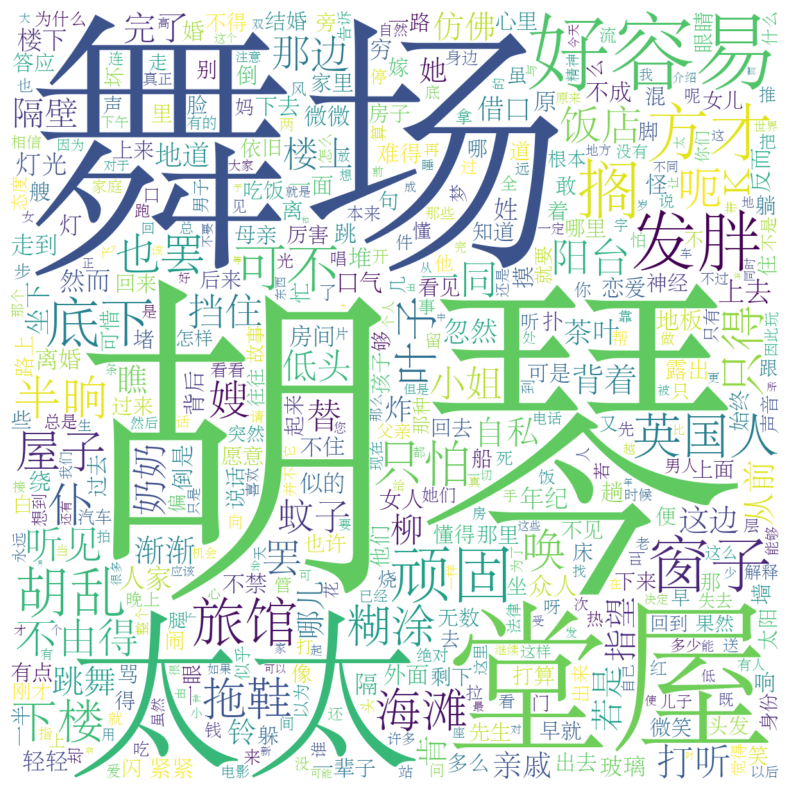

In [ ]:
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from PIL import Image

# Convert back to a dictionary (WordCloud requires a dictionary)
frequencies_dict = dict(token_ratios_list)

# Generate word cloud
wordcloud = WordCloud(font_path='STSong.ttf', colormap="viridis", max_words=500, width=1200, height=1200, background_color='white')

wordcloud.generate_from_frequencies(frequencies_dict)

# Display the generated word cloud
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig("wordcloud.png", format="png", dpi=300, bbox_inches="tight")
plt.show()

We can also use a mask to give the wordcloud a specific shape. The generation will take much longer though (around 2 mins for these particular settings!)

--2024-06-17 08:00:53--  https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/woman_silhouette.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 316910 (309K) [image/png]
Saving to: ‘woman_silhouette.png.4’

woman_silhouette.pn 100%[===================>] 309.48K  --.-KB/s    in 0.04s   

2024-06-17 08:00:54 (7.37 MB/s) - ‘woman_silhouette.png.4’ saved [316910/316910]



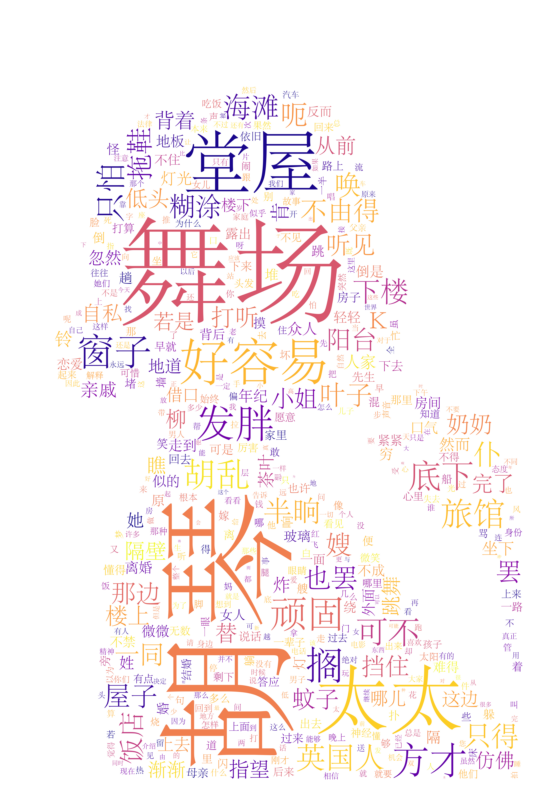

In [205]:
!wget https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/woman_silhouette.png
mask = np.array(Image.open('woman_silhouette.png'))

# Generate word cloud
wordcloud = WordCloud(font_path='STSong.ttf', mask=mask, colormap='plasma', max_words=500, width=1200, height=1200, background_color='white')
wordcloud.generate_from_frequencies(frequencies_dict)

# Display the generated word cloud
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig("wordcloud_masked.png", format="png", dpi=300, bbox_inches="tight")
plt.show()